In [1]:
import pandas as pd

# Load cleaned Thursday data
data = pd.read_csv('thursday_plus_cleaned.csv')
print("✅ Data loaded")
print("🔍 Unique Labels:", data['Label'].unique())


✅ Data loaded
🔍 Unique Labels: ['Benign' 'Web Attack - Brute Force - Attempted'
 'Web Attack - Brute Force' 'Infiltration - Attempted' 'Infiltration'
 'Infiltration - Portscan' 'Web Attack - XSS - Attempted'
 'Web Attack - XSS' 'Web Attack - SQL Injection - Attempted'
 'Web Attack - SQL Injection']


In [2]:
# 0 for Benign, 1 for Attack
data['is_attack'] = data['Label'].apply(lambda x: 0 if x == 'Benign' else 1)

# Multiclass label for specific attack
data['attack_type'] = data['Label']


In [3]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['Label', 'is_attack', 'attack_type'])
y_binary = data['is_attack']
y_multi = data['attack_type']

X_train, X_test, yb_train, yb_test = train_test_split(X, y_binary, test_size=0.3, random_state=42)
_, _, ym_train, ym_test = train_test_split(X, y_multi, test_size=0.3, random_state=42)


In [6]:
import numpy as np
X = data.drop(columns=['Label', 'is_attack', 'attack_type'])
X = X.select_dtypes(include=[np.number])




In [7]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['Label', 'is_attack', 'attack_type'])
y_binary = data['is_attack']
y_multi = data['attack_type']

X_train, X_test, yb_train, yb_test = train_test_split(X, y_binary, test_size=0.3, random_state=42)
_, _, ym_train, ym_test = train_test_split(X, y_multi, test_size=0.3, random_state=42)


In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load your cleaned CSV
data = pd.read_csv("thursday_plus_cleaned.csv")

# Add binary and multiclass labels
data['is_attack'] = data['Label'].apply(lambda x: 0 if x == 'Benign' else 1)
data['attack_type'] = data['Label']

# Drop unwanted columns
X = data.drop(columns=['Label', 'is_attack', 'attack_type'])

# ✅ Keep only numeric columns
X = X.select_dtypes(include=[np.number])

# Define labels
y_binary = data['is_attack']
y_multi = data['attack_type']

X_train, X_test, yb_train, yb_test = train_test_split(X, y_binary, test_size=0.3, random_state=42)
_, _, ym_train, ym_test = train_test_split(X, y_multi, test_size=0.3, random_state=42)

binary_rf = RandomForestClassifier(n_estimators=100, random_state=42)
binary_rf.fit(X_train, yb_train)

y_binary_pred = binary_rf.predict(X_test)
print("📊 Binary Classification Report:")
print(classification_report(yb_test, y_binary_pred, target_names=["Benign", "Attack"]))

multi_rf = RandomForestClassifier(n_estimators=100, random_state=42)
multi_rf.fit(X_train, ym_train)

y_multi_pred = multi_rf.predict(X_test)
print("📊 Multiclass Classification Report:")
print(classification_report(ym_test, y_multi_pred))

sample = X_test.iloc[0:1]

print("🚨 Is it an attack?", "Yes" if binary_rf.predict(sample)[0] == 1 else "No")
print("🔍 Attack type:", multi_rf.predict(sample)[0])




📊 Binary Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     86230
      Attack       1.00      1.00      1.00     21145

    accuracy                           1.00    107375
   macro avg       1.00      1.00      1.00    107375
weighted avg       1.00      1.00      1.00    107375

📊 Multiclass Classification Report:


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                                        precision    recall  f1-score   support

                                Benign       1.00      1.00      1.00     86230
                          Infiltration       1.00      0.79      0.88        14
              Infiltration - Attempted       1.00      0.77      0.87        13
               Infiltration - Portscan       1.00      1.00      1.00     20528
              Web Attack - Brute Force       1.00      0.96      0.98        24
  Web Attack - Brute Force - Attempted       0.84      0.90      0.87       385
            Web Attack - SQL Injection       1.00      1.00      1.00         4
Web Attack - SQL Injection - Attempted       0.00      0.00      0.00         2
                      Web Attack - XSS       1.00      1.00      1.00         4
          Web Attack - XSS - Attempted       0.74      0.63      0.68       171

                              accuracy                           1.00    107375
                             macro avg

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


First 10 predictions vs actual labels:
Sample 1: Predicted = 0, Actual = 0
Sample 2: Predicted = 0, Actual = 0
Sample 3: Predicted = 0, Actual = 0
Sample 4: Predicted = 0, Actual = 0
Sample 5: Predicted = 0, Actual = 0
Sample 6: Predicted = 0, Actual = 0
Sample 7: Predicted = 0, Actual = 0
Sample 8: Predicted = 0, Actual = 0
Sample 9: Predicted = 0, Actual = 0
Sample 10: Predicted = 0, Actual = 0

Accuracy: 0.9999

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     86230
           1       1.00      1.00      1.00     21145

    accuracy                           1.00    107375
   macro avg       1.00      1.00      1.00    107375
weighted avg       1.00      1.00      1.00    107375



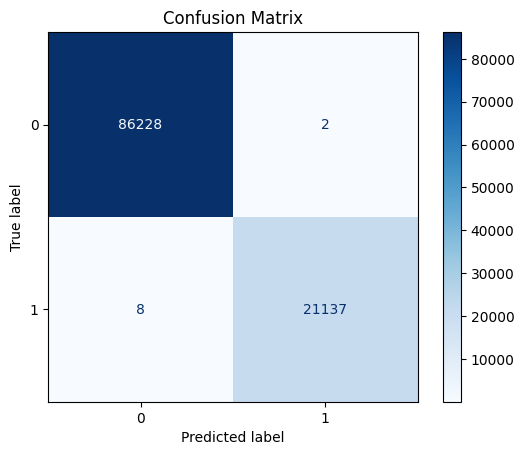

In [27]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model = binary_rf
y_pred = model.predict(X_test)

print("First 10 predictions vs actual labels:")
for i in range(10):
    print(f"Sample {i+1}: Predicted = {y_pred[i]}, Actual = {yb_test.iloc[i]}")

accuracy = accuracy_score(yb_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(yb_test, y_pred, zero_division=0))

cm = confusion_matrix(yb_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()





In [29]:
# Use your actual training labels variable name here
train_labels = yb_train  # or ym_train for multiclass

# Use your actual test labels variable name here
test_labels = yb_test  # or ym_test for multiclass

# Predict on training data
y_train_pred = model.predict(X_train)

# Calculate training accuracy
train_accuracy = accuracy_score(train_labels, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")

# Predict on test data (if you haven't yet)
y_test_pred = model.predict(X_test)

# Calculate test accuracy
test_accuracy = accuracy_score(test_labels, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Optional: print classification reports
print("\nTraining Classification Report:")
print(classification_report(train_labels, y_train_pred, zero_division=0))

print("\nTest Classification Report:")
print(classification_report(test_labels, y_test_pred, zero_division=0))


Training Accuracy: 1.0000
Test Accuracy: 0.9999

Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    200927
           1       1.00      1.00      1.00     49612

    accuracy                           1.00    250539
   macro avg       1.00      1.00      1.00    250539
weighted avg       1.00      1.00      1.00    250539


Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     86230
           1       1.00      1.00      1.00     21145

    accuracy                           1.00    107375
   macro avg       1.00      1.00      1.00    107375
weighted avg       1.00      1.00      1.00    107375

